### Supplementary: Sensitivity Analysis on Number of Compartments (n)

In [1]:
import pandas as pd
import util
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
Re_list     = pd.read_csv('data/mock dataset/Re_list.csv',  header=None)[0].to_numpy()
Scvector    = pd.read_csv('data/mock dataset/Scvector.csv',  header=None)[0].to_numpy()
Swvector    = pd.read_csv('data/mock dataset/Swvector.csv',  header=None)[0].to_numpy()
tvector     = pd.read_csv('data/mock dataset/tvector.csv',   header=None)[0].to_numpy()
t_ww_data   = pd.read_csv('data/mock dataset/t_ww.csv',      header=None)[0].to_numpy()
t_case_data = pd.read_csv('data/mock dataset/t_cases.csv',   header=None)[0].to_numpy()
cases_data  = pd.read_csv('data/mock dataset/cases.csv',     header=None)[0].to_numpy()
ww_data     = pd.read_csv('data/mock dataset/ww.csv',        header=None)[0].to_numpy()

start, end = 13880, 21190
mask_c = (t_case_data >= start/10) & (t_case_data <= end/10)
mask_w = (t_ww_data   >= start/10) & (t_ww_data   <= end/10)

case_mock = pd.DataFrame({'date_c': t_case_data[mask_c], 'noisy_c_values': cases_data[mask_c]})
ww_mock   = pd.DataFrame({'date_w': t_ww_data[mask_w],   'noisy_w_values': ww_data[mask_w]})
case_empt = pd.DataFrame(columns=['date_c', 'noisy_c_values'])
ww_empt   = pd.DataFrame(columns=['date_w', 'noisy_w_values'])

dt_real     = 0.1
sub_t       = tvector[start:end]
weekly_time = sub_t[70::70]

In [3]:
def make_profiles(n):
    """Return (c_i, omega_i, f_i) for a given number of compartments n.

    The same (r, p) parameters are used for all n; only the support size k=n
    changes.  With nu=1/n each compartment spans ~1 day, so the biological
    distributions remain time-scale invariant.
    """
    c_i     = util.generate_neg_binom(n, 11.528428093645484,       0.8               )
    omega_i = util.generate_neg_binom(n,  3.1515151515151514, 0.24444444444444444)
    f_i     = util.generate_neg_binom(n,  3.8989898989898992, 0.4473684210526315 )
    return c_i, omega_i, f_i

In [4]:
def get_logL_Joint(Casedata, WWdata, n_particles, epiparams,
                   c_i, omega_i, f_i, burnin_point=0):
    Re_curr      = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    log10_I_init = np.random.normal(loc=2.5, scale=1.0, size=n_particles)
    I_curr       = np.zeros((n_particles, epiparams['n']))
    I_curr[:, 0] = 10**log10_I_init

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    Re, wmean = [], []
    cumulative_incidence_record   = []
    wastewater_concentration_record = []
    I_record                      = []

    n_timepts = len(epiparams['tList'])
    t_day     = []

    ancestry      = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)

    for t_idx in range(n_timepts - 1):
        dRe     = epiparams['sigma_Re'] * np.random.randn(n_particles, 1) * dt_real
        Re_curr = np.clip(Re_curr + dRe, 0, 30)

        dt   = epiparams['tList'][t_idx + 1] - epiparams['tList'][t_idx]
        n_nu = epiparams['n'] * epiparams['nu']
        dI   = np.zeros_like(I_curr)

        Psi         = n_nu * Re_curr.flatten() * (I_curr @ f_i)
        dI[:, 0]    = Psi - n_nu * I_curr[:, 0]
        n_end       = epiparams['n']
        dI[:, 1:n_end-1] = (
            n_nu * I_curr[:, :n_end-2] - n_nu * I_curr[:, 1:n_end-1]
        )
        dI[:, n_end-1] = n_nu * I_curr[:, n_end-2]

        dSc = n_nu * epiparams['rho'] * (I_curr @ c_i)
        dSw = epiparams['lambda_ww'] * (I_curr @ omega_i) - epiparams['delta_ww'] * Sw_curr

        I_curr  += dI * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt

        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())

        date_c_list  = Casedata['date_c'].tolist()
        date_w_list  = WWdata['date_w'].tolist()
        joint_list   = sorted(set(date_c_list) | set(date_w_list))
        compare_time = epiparams['tList'][t_idx + 1]

        if compare_time in joint_list:
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                Sw_flat = np.array(Sw_curr).flatten()
                obsWW   = WWdata['noisy_w_values'][WWdata['date_w'] == compare_time]
                cv2     = epiparams['cv_ww'] ** 2
                ll_ww   = stats.gamma.pdf(obsWW, a=1.0/cv2, scale=Sw_flat * cv2)
                likelihoods *= np.ravel(ll_ww)

            if compare_time in date_c_list:
                steps_back = int(7 / dt_real)
                if len(cumulative_incidence_record) > steps_back:
                    cur_idx  = len(cumulative_incidence_record) - 1
                    week_idx = cur_idx - steps_back
                    w_inc    = np.zeros(n_particles)
                    for p in range(n_particles):
                        anc = p
                        for t in range(cur_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        w_inc[p] = (cumulative_incidence_record[cur_idx][p]
                                    - cumulative_incidence_record[week_idx][anc])
                else:
                    w_inc = cumulative_incidence_record[-1].copy()

                w_inc   = np.array(w_inc).flatten()
                obsCase = Casedata['noisy_c_values'][Casedata['date_c'] == compare_time]
                k_c     = epiparams['k_c']
                ll_case = stats.nbinom.pmf(obsCase, k_c, k_c / (k_c + w_inc))
                likelihoods *= np.ravel(ll_case)

            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr   = I_curr[k_vector, :]
            Sc_curr  = Sc_curr[k_vector]
            Sw_curr  = Sw_curr[k_vector]
            Re_curr  = Re_curr[k_vector]
            t_day.append(compare_time)
            wmean.append(np.mean(likelihoods))

    t_day_arr  = np.asarray(t_day)
    wmean_arr  = np.asarray(wmean)
    keep_mask  = t_day_arr >= burnin_point
    theta_logL = np.sum(np.log(np.maximum(wmean_arr[keep_mask], np.finfo(float).tiny)))

    fp   = np.random.randint(n_particles)
    traj = [fp]
    for t in range(n_timepts - 1, 0, -1):
        fp = ancestry[t, fp]
        traj.insert(0, fp)

    recon = {
        'Re':               np.array([Re[t][traj[t]]                         for t in range(len(Re))]),
        't':                epiparams['tList'][1:],
        'I_record':         np.array([I_record[t][traj[t], :]                for t in range(len(I_record))]),
        'Cumulative':       np.array([cumulative_incidence_record[t][traj[t]] for t in range(len(cumulative_incidence_record))]),
        'WW_concentration': np.array([wastewater_concentration_record[t][traj[t]] for t in range(len(wastewater_concentration_record))]),
    }
    recon['w_incidence'] = util.calculate_weekly_incidence(recon['Cumulative'])
    return theta_logL, recon

In [8]:
"""
Fit NegBin delay kernels for n = 6, 8, ..., 64.

For each n, this fits:
    c_i     : case detection / incubation kernel
    omega_i : shedding / wastewater kernel
    f_i     : infectivity / generation kernel

The fitted parameters are stored in fitted_params_by_n.

Then make_profiles(n) returns the fitted profiles for that n.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, nbinom, gaussian_kde
from scipy.optimize import differential_evolution

np.random.seed(48)

# ============================================================
# 1. Target biological distributions
# ============================================================

N_TIME = 3000

# Use a global target grid long enough for every n.
# Since n goes up to 64 and we use ~1 day per compartment,
# the maximum support is approximately 63 days.
T_TARGET_MAX = 64.0
t_target = np.linspace(0, T_TARGET_MAX, N_TIME)

# -- Shedding load duration
mean_sld, sd_sld = 6.7, 7.0
shape_sld = (mean_sld / sd_sld) ** 2
scale_sld = (sd_sld ** 2) / mean_sld

# -- Incubation period
mean_incubation, sd_incubation = 5.3, 3.2
shape_incubation = (mean_incubation / sd_incubation) ** 2
scale_incubation = (sd_incubation ** 2) / mean_incubation

# -- Generation time
shape_generation = 2.39
scale_generation = 2.95

# Continuous target PDFs
incubation_pdf_full = gamma.pdf(
    t_target,
    shape_incubation,
    scale=scale_incubation,
)

generation_pdf_full = gamma.pdf(
    t_target,
    shape_generation,
    scale=scale_generation,
)

# Combined SLD + incubation via Monte Carlo convolution
samples_sld = np.random.gamma(shape_sld, scale_sld, 20_000)
samples_incubation = np.random.gamma(shape_incubation, scale_incubation, 20_000)
combined_samples = samples_sld + samples_incubation
combined_pdf_full = gaussian_kde(combined_samples)(t_target)


def normalize_pdf(pdf, t):
    area = np.trapz(pdf, t)
    if area <= 0 or not np.isfinite(area):
        return np.ones_like(pdf) / np.trapz(np.ones_like(pdf), t)
    return pdf / area


combined_pdf_full = normalize_pdf(combined_pdf_full, t_target)
incubation_pdf_full = normalize_pdf(incubation_pdf_full, t_target)
generation_pdf_full = normalize_pdf(generation_pdf_full, t_target)

targets_full = {
    "c": {
        "target_pdf": incubation_pdf_full,
        "title": "c_i: incubation / case detection",
    },
    "omega": {
        "target_pdf": combined_pdf_full,
        "title": "omega_i: SLD + incubation",
    },
    "f": {
        "target_pdf": generation_pdf_full,
        "title": "f_i: generation / infectivity",
    },
}


# ============================================================
# 2. Fast NegBin helper functions
# ============================================================

def make_negbin_weights_fixed_time(n, mean_days, scale, total_time):
    """
    Return NegBin weights over n compartments.

    mean_days is the desired mean in biological time.
    scale is the NegBin size / dispersion parameter r.

    Internally:
        dt = total_time / (n - 1)
        mean_index = mean_days / dt

    SciPy uses:
        mean_index = r * (1 - p) / p

    so:
        p = r / (r + mean_index)
    """
    if n < 2:
        raise ValueError("n must be at least 2.")

    dt = total_time / (n - 1)
    mean_index = mean_days / dt

    mean_index = max(mean_index, 1e-10)
    r = max(scale, 1e-10)
    p = r / (r + mean_index)

    indices = np.arange(n)
    weights = nbinom.pmf(indices, r, p)

    total = weights.sum()
    if total <= 0 or not np.isfinite(total):
        return np.ones(n) / n

    return weights / total


def make_interpolation_matrix(n, t, total_time):
    """
    Precompute matrix A so that:

        model_pdf = A @ weights

    This makes optimization much faster than calling np.interp repeatedly.
    """
    compartment_times = np.linspace(0, total_time, n)

    A = np.zeros((len(t), n))

    idx_right = np.searchsorted(compartment_times, t, side="left")
    idx_right = np.clip(idx_right, 0, n - 1)
    idx_left = np.clip(idx_right - 1, 0, n - 1)

    t_left = compartment_times[idx_left]
    t_right = compartment_times[idx_right]

    denom = t_right - t_left
    denom[denom == 0] = 1.0

    w_right = (t - t_left) / denom
    w_left = 1.0 - w_right

    rows = np.arange(len(t))
    A[rows, idx_left] += w_left
    A[rows, idx_right] += w_right

    return A


def pdf_moments(t, pdf):
    pdf = normalize_pdf(pdf, t)
    mean = np.trapz(t * pdf, t)
    var = np.trapz((t - mean) ** 2 * pdf, t)
    return mean, np.sqrt(var)


def bounds_from_target(t, target_pdf, total_time):
    """
    Bounds are in real biological time, then clipped to the available
    support for this n.
    """
    m, sd = pdf_moments(t, target_pdf)

    mean_lower = max(0.05, m - 3.0 * sd)
    mean_upper = min(total_time - 0.05, m + 3.0 * sd)

    if mean_upper <= mean_lower:
        mean_lower = 0.05
        mean_upper = max(0.10, total_time - 0.05)

    # Optimize log(scale) for numerical stability.
    log_scale_lower = np.log(0.05)
    log_scale_upper = np.log(200.0)

    return [
        (mean_lower, mean_upper),
        (log_scale_lower, log_scale_upper),
    ]


def fit_one_kernel_for_n(n, target_pdf_full, total_time):
    """
    Fit one NegBin kernel for a given n.
    """
    # Use only the part of the target distribution that this n can represent.
    mask = t_target <= total_time
    t = t_target[mask]
    target_pdf = target_pdf_full[mask]
    target_pdf = normalize_pdf(target_pdf, t)

    A = make_interpolation_matrix(n, t, total_time)
    bounds = bounds_from_target(t, target_pdf, total_time)

    def objective(params):
        mean_days = params[0]
        scale = np.exp(params[1])

        weights = make_negbin_weights_fixed_time(
            n=n,
            mean_days=mean_days,
            scale=scale,
            total_time=total_time,
        )

        model_pdf = A @ weights
        model_pdf = normalize_pdf(model_pdf, t)

        return np.mean((model_pdf - target_pdf) ** 2)

    result = differential_evolution(
        objective,
        bounds=bounds,
        seed=48,
        tol=1e-7,
        polish=True,
        workers=1,
        updating="immediate",
    )

    best_mean_days = result.x[0]
    best_scale = np.exp(result.x[1])

    best_weights = make_negbin_weights_fixed_time(
        n=n,
        mean_days=best_mean_days,
        scale=best_scale,
        total_time=total_time,
    )

    best_model_pdf = A @ best_weights
    best_model_pdf = normalize_pdf(best_model_pdf, t)

    return {
        "n": n,
        "total_time": total_time,
        "mean_days": best_mean_days,
        "scale": best_scale,
        "loss": result.fun,
        "weights": best_weights,
        "t": t,
        "target_pdf": target_pdf,
        "model_pdf": best_model_pdf,
        "optimizer_result": result,
    }



/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_78969/1116887305.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, t)


In [9]:
# ============================================================
# 3. Fit all n values, fixed total time = 40 days
# ============================================================

TOTAL_TIME = 40.0
NU = 1 / 40

n_values_ll = list(range(6, 65, 2))

fitted_results_by_n = {}
fitted_params_by_n = {}

for n in n_values_ll:
    print(f"\nFitting n = {n}")

    fitted_results_by_n[n] = {}
    fitted_params_by_n[n] = {}

    for kernel_name, info in targets_full.items():
        result = fit_one_kernel_for_n(
            n=n,
            target_pdf_full=info["target_pdf"],
            total_time=TOTAL_TIME,
        )

        fitted_results_by_n[n][kernel_name] = result

        fitted_params_by_n[n][kernel_name] = {
            "mean_days": result["mean_days"],
            "scale": result["scale"],
            "loss": result["loss"],
        }

        print(
            f"  {kernel_name:>5s} | "
            f"mean_days = {result['mean_days']:8.4f}, "
            f"scale = {result['scale']:8.4f}, "
            f"loss = {result['loss']:.6e}"
        )


Fitting n = 6
      c | mean_days =   3.4782, scale = 199.9996, loss = 5.428832e-04
  omega | mean_days =  10.4548, scale = 199.9999, loss = 1.208847e-04


/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_78969/1116887305.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, t)
/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_78969/1116887305.py:169: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean = np.trapz(t * pdf, t)
/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_78969/1116887305.py:170: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  var = np.trapz((t - mean) ** 2 * pdf, t)


      f | mean_days =   5.4170, scale = 199.9999, loss = 2.683843e-04

Fitting n = 8
      c | mean_days =   4.3354, scale = 200.0000, loss = 4.411121e-04
  omega | mean_days =  10.5661, scale = 200.0000, loss = 6.783066e-05
      f | mean_days =   5.9643, scale = 199.9999, loss = 1.767542e-04

Fitting n = 10
      c | mean_days =   4.6077, scale = 199.9997, loss = 3.295564e-04
  omega | mean_days =  10.5312, scale = 200.0000, loss = 3.817650e-05
      f | mean_days =   6.1438, scale = 200.0000, loss = 1.128585e-04

Fitting n = 12
      c | mean_days =   4.7214, scale = 199.9999, loss = 2.445681e-04
  omega | mean_days =  10.4280, scale = 199.9998, loss = 2.445079e-05
      f | mean_days =   6.2107, scale = 200.0000, loss = 7.229111e-05

Fitting n = 14
      c | mean_days =   4.7789, scale = 200.0000, loss = 1.818793e-04
  omega | mean_days =  10.5434, scale =  20.1110, loss = 1.958950e-05
      f | mean_days =   6.2234, scale = 199.9999, loss = 4.770607e-05

Fitting n = 16
      c | m

In [10]:
def make_profiles(n):
    """
    Return fitted profiles (c_i, omega_i, f_i) for a given number of compartments n.

    Total biological time is fixed at 40 days for every n.
    Therefore, changing n only changes the resolution of the discrete approximation.
    """
    if n not in fitted_params_by_n:
        raise ValueError(
            f"n={n} was not fitted. "
            f"Available n values: {list(fitted_params_by_n.keys())}"
        )

    c_par = fitted_params_by_n[n]["c"]
    omega_par = fitted_params_by_n[n]["omega"]
    f_par = fitted_params_by_n[n]["f"]

    c_i = make_negbin_weights_fixed_time(
        n=n,
        mean_days=c_par["mean_days"],
        scale=c_par["scale"],
        total_time=TOTAL_TIME,
    )

    omega_i = make_negbin_weights_fixed_time(
        n=n,
        mean_days=omega_par["mean_days"],
        scale=omega_par["scale"],
        total_time=TOTAL_TIME,
    )

    f_i = make_negbin_weights_fixed_time(
        n=n,
        mean_days=f_par["mean_days"],
        scale=f_par["scale"],
        total_time=TOTAL_TIME,
    )

    return c_i, omega_i, f_i

In [19]:
# ============================================================
# 6. Log-likelihood sensitivity to n
# ============================================================

np.random.seed(0)

n_values_ll = list(range(6, 65, 2))
n_repl_n = 10
n_particles_ll = 1000

logL_by_n = np.empty((len(n_values_ll), n_repl_n))

for i, n in enumerate(n_values_ll):
    c_i_n, omega_i_n, f_i_n = make_profiles(n)

    ep = {
        "n": n,
        "sigma_Re": 0.6,
        "lambda_ww": 5000,
        "delta_ww": 0.5,
        "cv_ww": 0.1,
        "k_c": 10,
        "nu": 1 / 40,
        "dt": dt_real,
        "time_start_day": 1388,
        "time_end_day": 2119,
        "tList": tvector[start:end],
        "rho": 0.1,
    }

    for r in range(n_repl_n):
        logL_by_n[i, r], _ = get_logL_Joint(
            case_mock,
            ww_mock,
            n_particles_ll,
            ep,
            c_i_n,
            omega_i_n,
            f_i_n,
            burnin_point=1460,
        )

    print(
        f"n={n:3d}  "
        f"mean={logL_by_n[i].mean():.1f}  "
        f"median={np.median(logL_by_n[i]):.1f}"
    )

mean_logL_n = logL_by_n.mean(axis=1)
median_logL_n = np.median(logL_by_n, axis=1)
stderr_logL_n = logL_by_n.std(axis=1) / np.sqrt(n_repl_n)

#np.save("supp_results/median_logL_varying_n_refit.npy", median_logL_n)
#np.save("supp_results/logL_varying_n_refit.npy", logL_by_n)

n=  6  mean=-11041.2  median=-10958.6
n=  8  mean=-6392.7  median=-6369.2
n= 10  mean=-3754.8  median=-3639.0
n= 12  mean=-3367.8  median=-3324.8
n= 14  mean=-3271.1  median=-3202.7
n= 16  mean=-3098.2  median=-3071.0
n= 18  mean=-3013.7  median=-3010.3
n= 20  mean=-2971.2  median=-2954.6
n= 22  mean=-2932.9  median=-2940.6
n= 24  mean=-2927.1  median=-2924.9
n= 26  mean=-2883.8  median=-2867.9
n= 28  mean=-2869.2  median=-2852.3
n= 30  mean=-2846.9  median=-2841.0
n= 32  mean=-2831.2  median=-2829.1
n= 34  mean=-2838.6  median=-2832.8
n= 36  mean=-2821.1  median=-2820.0
n= 38  mean=-2842.4  median=-2820.1
n= 40  mean=-2841.0  median=-2819.7
n= 42  mean=-2817.0  median=-2812.5
n= 44  mean=-2835.8  median=-2818.2
n= 46  mean=-2822.8  median=-2815.0
n= 48  mean=-2819.7  median=-2812.1
n= 50  mean=-2828.2  median=-2819.0
n= 52  mean=-2822.7  median=-2816.2
n= 54  mean=-2837.2  median=-2829.4
n= 56  mean=-2842.7  median=-2827.9
n= 58  mean=-2844.7  median=-2832.4
n= 60  mean=-2862.2  media

In [13]:
n_values_ll = np.load("supp_results/logL_varying_n_refit.npy")
median_logL_n = np.load("supp_results/median_logL_varying_n_refit.npy")

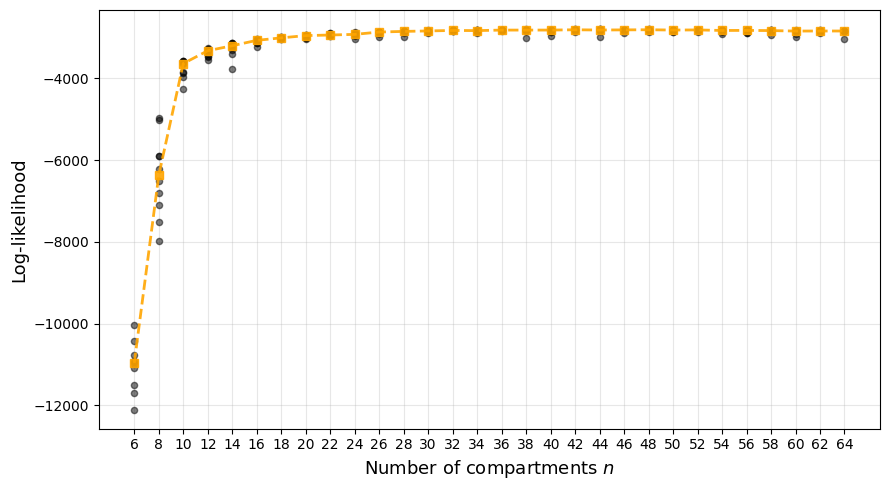

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

# --- Scatter individual replicate values ---
for i, n in enumerate(n_values_ll):
    x_vals = np.full(n_repl_n, n)  # same x for all replicates
    ax.scatter(
        x_vals,
        logL_by_n[i],
        color='black',
        alpha=0.5,
        s=20,
        zorder=2
    )

# --- Median line ---
ax.plot(
    n_values_ll,
    median_logL_n,
    's--',
    color='orange',
    lw=2.0,
    ms=6,
    alpha=0.9,
    label='Median log-likelihood',
    zorder=3
)

ax.set_xticks(n_values_ll)
ax.set_xlabel('Number of compartments $n$', fontsize=13)
ax.set_ylabel('Log-likelihood', fontsize=13)
# ax.set_ylim(-8000, median_logL_n.max() + 50)
ax.grid(True, alpha=0.3)
# ax.legend()

plt.tight_layout()
plt.show()

In [15]:
np.random.seed(42)
n_particles = 1000
n_values    = [20, 40, 60]
recon_by_n  = {}

for n in n_values:
    c_i, omega_i, f_i = make_profiles(n)
    epiparams = {
        'n'             : n,
        'sigma_Re'      : 0.6,
        'lambda_ww'     : 5000,
        'delta_ww'      : 0.5,
        'cv_ww'         : 0.1,
        'k_c'           : 10,
        'nu'            : 1 / 40,      # keeps 1 compartment ≈ 1 day
        'dt'            : dt_real,
        'time_start_day': 1388,
        'time_end_day'  : 2119,
        'tList'         : tvector[start:end],
        'rho'           : 0.1
    }
    _, recon = get_logL_Joint(
        case_mock, ww_mock, n_particles, epiparams,
        c_i, omega_i, f_i, burnin_point=1460
    )
    recon_by_n[n] = recon
    print(f'Completed n={n}')

Completed n=20
Completed n=40
Completed n=60


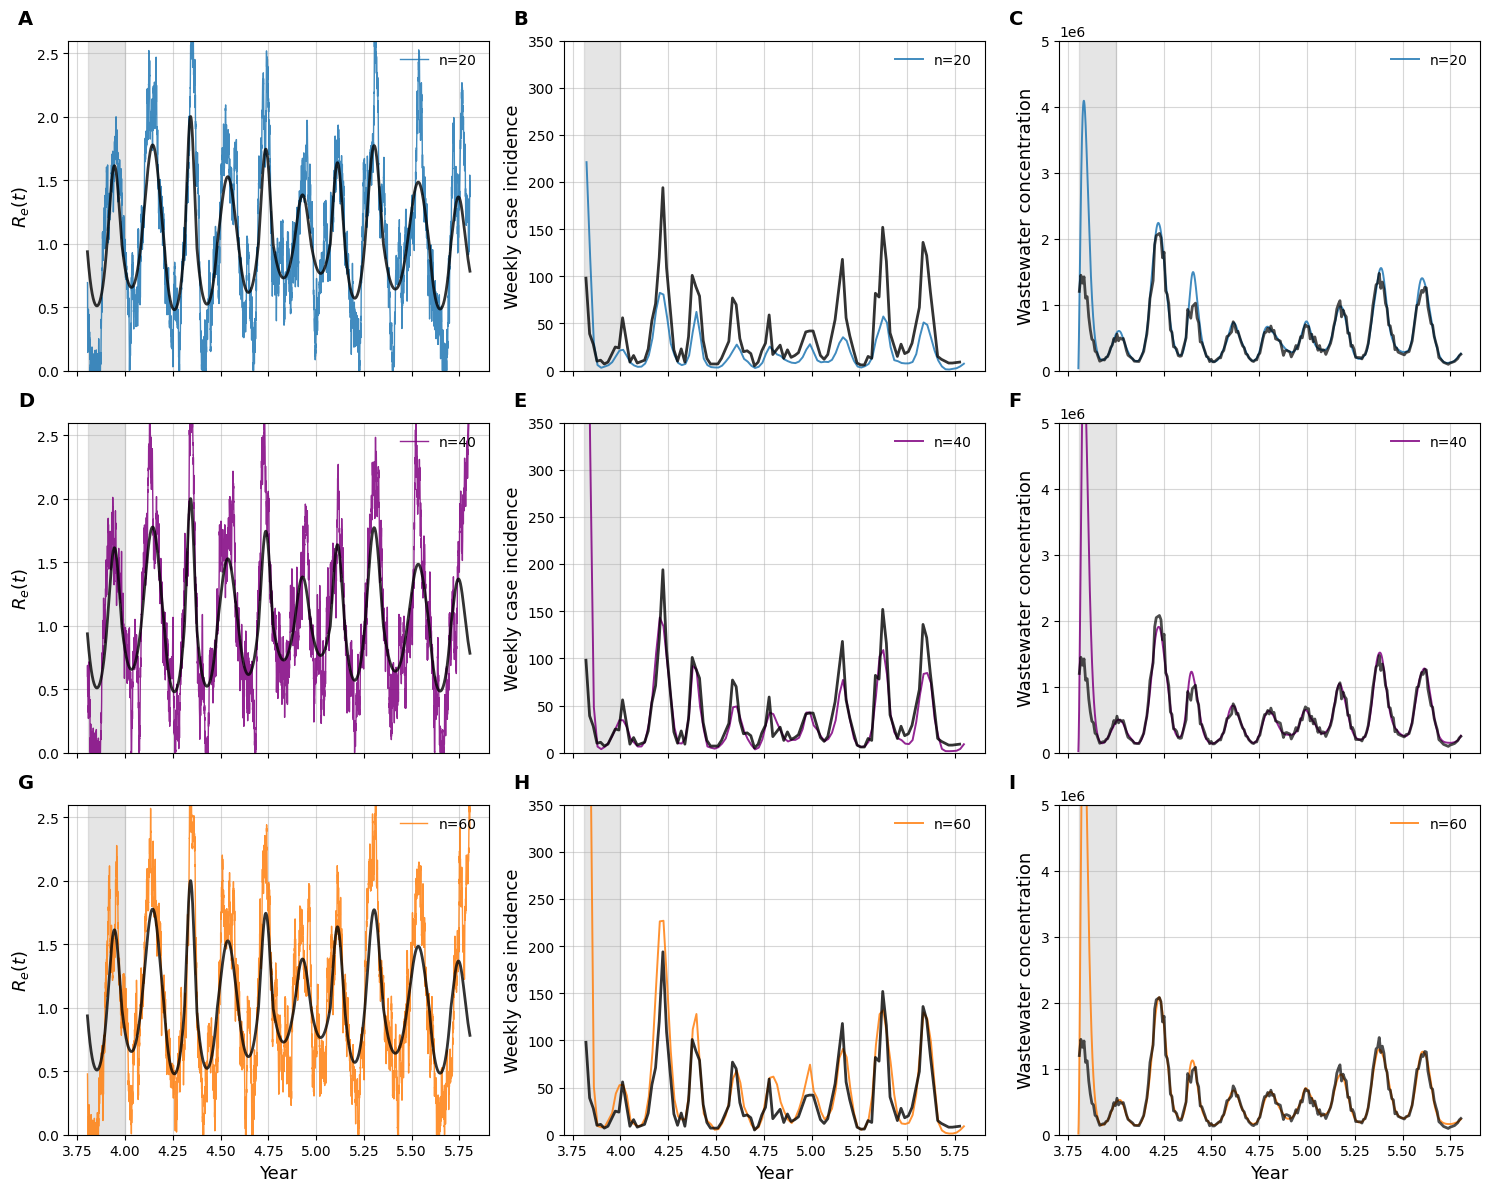

In [16]:
label_font  = {'fontsize': 13}
colors      = {20: 'tab:blue', 40: 'purple', 60: 'tab:orange'}
burnin_span = (1390/365, 1460/365)
letters     = list('ABCDEFGHI')

fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
col_titles = ['Effective Reproduction Number',
              'Weekly Case Incidence',
              'Wastewater Concentration']

for row, n in enumerate(n_values):
    recon  = recon_by_n[n]
    t_year = recon['t'] / 365
    col    = colors[n]

    # ── Rt ──────────────────────────────────────────────────────────────────
    ax = axs[row, 0]
    ax.plot(t_year, recon['Re'], color=col, lw=1.0, alpha=0.85, label=f'n={n}')
    ax.plot(tvector[start:end]/365, Re_list[start:end],
            color='black', lw=2.0, alpha=0.8)
    ax.axvspan(*burnin_span, color='grey', alpha=0.2)
    ax.set_ylabel('$R_e(t)$', **label_font)
    ax.grid(True, alpha=0.5)
    ax.legend(loc='upper right', framealpha=0, fontsize=10)
    #if row == 0: ax.set_title(col_titles[0], **label_font)
    if row == 2: ax.set_xlabel('Year', **label_font)
    ax.text(-0.12, 1.05, letters[row*3],
            transform=ax.transAxes, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 2.6)

    # ── Weekly case incidence ───────────────────────────────────────────────
    ax = axs[row, 1]
    ax.plot(weekly_time/365, recon['w_incidence'],
            color=col, lw=1.4, alpha=0.85, label=f'n={n}')
    ax.plot(case_mock['date_c']/365, case_mock['noisy_c_values'],
            color='black', lw=2.0, alpha=0.8)
    ax.axvspan(*burnin_span, color='grey', alpha=0.2)
    ax.set_ylabel('Weekly case incidence', **label_font)
    ax.grid(True, alpha=0.5)
    ax.legend(loc='upper right', framealpha=0, fontsize=10)
    #if row == 0: ax.set_title(col_titles[1], **label_font)
    if row == 2: ax.set_xlabel('Year', **label_font)
    ax.text(-0.12, 1.05, letters[row*3+1],
            transform=ax.transAxes, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 350)

    # ── Wastewater concentration ────────────────────────────────────────────
    ax = axs[row, 2]
    ax.plot(t_year, recon['WW_concentration'],
            color=col, lw=1.4, alpha=0.85, label=f'n={n}')
    ax.plot(ww_mock['date_w']/365, ww_mock['noisy_w_values'],
            color='black', lw=2.0, alpha=0.7)
    ax.axvspan(*burnin_span, color='grey', alpha=0.2)
    ax.set_ylabel('Wastewater concentration', **label_font)
    ax.set_ylim(0, 5e6)
    ax.grid(True, alpha=0.5)
    ax.legend(loc='upper right', framealpha=0, fontsize=10)
    #if row == 0: ax.set_title(col_titles[2], **label_font)
    if row == 2: ax.set_xlabel('Year', **label_font)
    ax.text(-0.12, 1.05, letters[row*3+2],
            transform=ax.transAxes, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 5e6)

plt.tight_layout()
plt.show()

### Supplementary: Sensitivity analysis of how we model the temporal variation in Re(t)


In [23]:

# ---------------------------------------------------------------------------
# Particle filter — Rt evolves in normal space (original BM)
# ---------------------------------------------------------------------------
def get_logL_Joint_prior (Casedata, WWdata, n_particles, epiparams, burnin_point = 0):
    Re_curr = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    mu, sigma = 2.5, 1.0
    log10_I_init = np.random.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10**log10_I_init
    I_curr = np.zeros((n_particles, epiparams["n"]))
    I_curr[:, 0] = I_init_total

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    # Initialize storage for simulation results
    Re, w_list, wmean = [], [], []
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []

    # Determine the number of time points
    n_timepts = len(epiparams["tList"])
    t_day = []              # times when resampling occurs
    
    ancestry = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)  # initial ancestry

    for t_idx in range(n_timepts - 1):
        # Brownian motion update for Re
        dRe = epiparams["sigma_Re"] * np.random.randn(n_particles, 1) * dt_real
        Re_curr = Re_curr + dRe  
        Re_curr = np.clip(Re_curr, 0, 30)
        
        dt = epiparams["tList"][t_idx + 1] - epiparams["tList"][t_idx]
        dI = np.zeros_like(I_curr)
        dSc = np.zeros(n_particles)
        dSw = np.zeros(n_particles)
        # Force of infection
        Psi = epiparams["n"] * epiparams["nu"] * Re_curr.flatten() * (I_curr[:, :epiparams["n"]] @ f_i)
        
        # Infection compartment dynamics
        dI[:, 0] = Psi - epiparams["n"] * epiparams["nu"] * I_curr[:, 0]
        dI[:, 1:epiparams["n"]-1] = -epiparams["n"] * epiparams["nu"] * I_curr[:, 1:epiparams["n"]-1] + epiparams["n"] * epiparams["nu"] * I_curr[:, :epiparams["n"]-2]
        dI[:, epiparams["n"]-1] = epiparams["n"] * epiparams["nu"] * I_curr[:, epiparams["n"]-2]
        
        # Cumulative incidence dynamics
        dSc = epiparams["n"] * epiparams["nu"] * epiparams["rho"] * (I_curr[:, :epiparams["n"]] @ c_i)
        # Wastewater dynamics
        dSw = epiparams["lambda_ww"] * (I_curr[:, :epiparams["n"]] @ omega_i) - epiparams["delta_ww"] * Sw_curr
        
        # Update the state vector using the Euler-Maruyama method
        I_curr[:, :epiparams["n"]] += dI[:, :epiparams["n"]] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt
        
        # Record simulation results
        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())
        
        date_c_list = Casedata["date_c"].tolist()
        date_w_list = WWdata["date_w"].tolist()
        joint_list = sorted(list(set(date_c_list) | set(date_w_list)))
    
        # Determine the current simulation time for potential observation
        compare_time = epiparams["tList"][t_idx + 1]

        if compare_time in joint_list:
            k_vector = np.arange(n_particles) 
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                # Retrieve the current wastewater concentration (flatten if needed)
                Sw_curr_flat = np.array(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                # Compute the gamma likelihood for the wastewater data
                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(1 / epiparams["cv_ww"]) ** 2,
                    scale=Sw_curr_flat * epiparams["cv_ww"] ** 2
                )
                likelihoods_ww = np.ravel(likelihoods_ww)
                likelihoods *= likelihoods_ww 

            if compare_time in date_c_list:
                # Ensure that we have enough recorded steps (at least 7 days worth)
                steps_back = int(7 / dt_real)
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1  # current time index
                    week_idx = current_idx - steps_back             # index 7 days ago
                    weekly_incidence = np.zeros(n_particles)
                    
                    # Trace the ancestry for each particle to pick the correct cumulative incidence from 7 days ago
                    for particle in range(n_particles):
                        anc = particle
                        # Trace ancestry from the current time back to week_idx
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        # Calculate weekly incidence along the same ancestral path
                        weekly_incidence[particle] = cumulative_incidence_record[current_idx][particle] - cumulative_incidence_record[week_idx][anc]
                else:
                    # If not enough time points have been recorded, use the current cumulative incidence
                    weekly_incidence = cumulative_incidence_record[-1]

                # Ensure weekly_incidence is a 1D numpy array of shape (n_particles,)
                weekly_incidence = np.array(weekly_incidence).flatten()
                
                # Retrieve the observed case(s) for this time point
                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                
                # Compute likelihoods using the negative binomial PMF
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    epiparams["k_c"],
                    epiparams["k_c"] / (epiparams["k_c"] + weekly_incidence)
                )
                # Ensure likelihoods is a 1D array
                likelihoods_case = np.ravel(likelihoods_case)
                likelihoods *= likelihoods_case 

            if np.isnan(likelihoods).any():
                import pdb; pdb.set_trace()  # or breakpoint()
                print("Warning: NaN values detected in likelihoods!")

            # Resample 
            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr = I_curr[k_vector, :]
            Sc_curr = Sc_curr[k_vector]
            Sw_curr = Sw_curr[k_vector]
            Re_curr = Re_curr[k_vector]
            t_day.append(compare_time)
            w_list.append(likelihoods)
            wmean.append(np.mean(likelihoods))

    t_day_arr = np.asarray(t_day)
    wmean_arr = np.asarray(wmean)

    keep_mask = t_day_arr >= burnin_point       # True → keep
    safe_w    = np.maximum(wmean_arr[keep_mask],
                           np.finfo(float).tiny)

    theta_logL = np.sum(np.log(safe_w))

    final_particle = np.random.randint(n_particles)
    trajectory_indices = [final_particle]
    for t in range(n_timepts - 1, 0, -1):
        final_particle = ancestry[t, final_particle]
        trajectory_indices.insert(0, final_particle)
    
    recon = {
        "Re": np.array([Re[t][trajectory_indices[t]] for t in range(len(Re))]),
        "t_day": np.array(t_day),
        "t": epiparams["tList"][1:],
        "I_record": np.array([I_record[t][trajectory_indices[t], :] for t in range(len(I_record))]),
        "Cumulative": np.array([cumulative_incidence_record[t][trajectory_indices[t]] for t in range(len(cumulative_incidence_record))]),
        "WW_concentration": np.array([wastewater_concentration_record[t][trajectory_indices[t]] for t in range(len(wastewater_concentration_record))]),
        "I_init_vals":     I_init_total, 
        "first_parents":   np.unique(ancestry[1389, :]),
        "ancestry": ancestry
    
    }

    w_incidence = util.calculate_weekly_incidence(recon["Cumulative"])
    sub_t  = np.arange(0, 140, dt_real)
    weekly_time = sub_t[70::70]
    recon["w_incidence"] = w_incidence
    recon["weekly_time"] = weekly_time
    d_incidence = util.calculate_daily_incidence(recon["Cumulative"])
    recon["d_incidence"] = d_incidence
    recon["daily_time"] = weekly_time = sub_t[10::10]
    recon["ess_values"] = [len(np.unique(ancestry[t, :])) for t in range(n_timepts)]
    recon["wmean"] = np.asarray(wmean)
    return theta_logL, recon


# ---------------------------------------------------------------------------
# Particle filter — log(Rt) evolves via BM  (new variant)
# ---------------------------------------------------------------------------
def get_logL_log_BM(Casedata, WWdata, n_particles, epiparams, burnin_point=0):
    """Brownian motion on log(Rt); Re = exp(log_Re)."""
    n  = epiparams["n"]
    nu = epiparams["nu"]

    Re_curr     = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    Log_Re_curr = np.log(Re_curr)

    mu, sigma = 2.5, 1.0
    log10_I_init = np.random.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10 ** log10_I_init

    I_curr  = np.zeros((n_particles, n))
    I_curr[:, 0] = I_init_total
    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    Re, wmean = [], []
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []

    n_timepts = len(epiparams["tList"])
    t_day     = []
    ancestry  = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)

    date_c_list = Casedata["date_c"].tolist()
    date_w_list = WWdata["date_w"].tolist()
    joint_list  = sorted(list(set(date_c_list) | set(date_w_list)))

    for t_idx in range(n_timepts - 1):
        # Log-space BM on Rt
        dlogRe      = epiparams["sigma_Re"] * np.random.randn(n_particles, 1) * dt_real
        Log_Re_curr = Log_Re_curr + dlogRe
        Re_curr     = np.exp(Log_Re_curr)

        dt  = epiparams["tList"][t_idx + 1] - epiparams["tList"][t_idx]
        dI  = np.zeros_like(I_curr)

        Psi = n * nu * Re_curr.flatten() * (I_curr @ f_i)

        dI[:, 0]     = Psi - n * nu * I_curr[:, 0]
        dI[:, 1:n-1] = -n * nu * I_curr[:, 1:n-1] + n * nu * I_curr[:, :n-2]
        dI[:, n-1]   = n * nu * I_curr[:, n-2]

        dSc = n * nu * epiparams["rho"] * (I_curr @ c_i)
        dSw = epiparams["lambda_ww"] * (I_curr @ omega_i) - epiparams["delta_ww"] * Sw_curr

        I_curr[:, :epiparams["n"]] += dI[:, :epiparams["n"]] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt

        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())

        compare_time = epiparams["tList"][t_idx + 1]

        if compare_time in joint_list:
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                Sw_curr_flat = np.array(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(1 / epiparams["cv_ww"]) ** 2,
                    scale=Sw_curr_flat * epiparams["cv_ww"] ** 2
                )
                likelihoods *= np.ravel(likelihoods_ww)

            if compare_time in date_c_list:
                steps_back = int(7 / dt_real)
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1
                    week_idx    = current_idx - steps_back
                    weekly_incidence = np.zeros(n_particles)
                    for particle in range(n_particles):
                        anc = particle
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        weekly_incidence[particle] = (
                            cumulative_incidence_record[current_idx][particle]
                            - cumulative_incidence_record[week_idx][anc]
                        )
                else:
                    weekly_incidence = cumulative_incidence_record[-1]

                weekly_incidence = np.array(weekly_incidence).flatten()
                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    epiparams["k_c"],
                    epiparams["k_c"] / (epiparams["k_c"] + weekly_incidence)
                )
                likelihoods *= np.ravel(likelihoods_case)

            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr      = I_curr[k_vector, :]
            Sc_curr     = Sc_curr[k_vector]
            Sw_curr     = Sw_curr[k_vector]
            Re_curr     = Re_curr[k_vector]
            Log_Re_curr = Log_Re_curr[k_vector]
            t_day.append(compare_time)
            wmean.append(np.mean(likelihoods))

    t_day_arr  = np.asarray(t_day)
    wmean_arr  = np.asarray(wmean)
    keep_mask  = t_day_arr >= burnin_point
    safe_w     = np.maximum(wmean_arr[keep_mask], np.finfo(float).tiny)
    return np.sum(np.log(safe_w))


In [25]:
# ---------------------------------------------------------------------------
# Shared parameters
# ---------------------------------------------------------------------------
dt_real = 0.1

epiparams = {
    "n":          40,
    "sigma_Re":   0.6,
    "lambda_ww":  7500,   # fixed
    "delta_ww":   0.5,
    "cv_ww":      0.1,
    "k_c":        10,
    "nu":         1/40,
    "dt":         dt_real,
    "time_start_day": 1388,
    "time_end_day":   2119,
    "tList":      tvector,
    "rho":        0.14,   # fixed
}

n  = epiparams["n"]
c_i     = util.generate_neg_binom(n, 11.528428093645484,      0.8)
omega_i = util.generate_neg_binom(n,  3.1515151515151514, 0.24444444444444444)
f_i     = util.generate_neg_binom(n,  3.8989898989898992, 0.4473684210526315)

n_particles = 1000

# ---------------------------------------------------------------------------
# Sigma sweep
# ---------------------------------------------------------------------------
#sigma_values = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60]
sigma_values = [
    0.40, 0.43, 0.46, 0.49, 0.52, 0.55, 0.58, 0.61, 0.64, 0.67,
    0.70, 0.73, 0.76, 0.79, 0.82, 0.85, 0.88, 0.91, 0.94, 0.97,
    1.00, 1.03, 1.06, 1.09, 1.12, 1.15, 1.18, 1.21, 1.24, 1.27,
    1.30, 1.33, 1.36, 1.40
]
ax.set_xlim(0.4, 1.4)

n_repl = 10

In [ ]:
# Shape: (n_sigma, n_repl)
logL_all_normal = np.empty((len(sigma_values), n_repl))
logL_all_log    = np.empty((len(sigma_values), n_repl))

for i, sigma in enumerate(sigma_values):
    epiparams["sigma_Re"] = sigma
    print(f"sigma = {sigma:.2f} ({i+1}/{len(sigma_values)})", flush=True)
    for r in range(n_repl):
        logL_all_normal[i, r] = get_logL_Joint_prior(
            case_mock, ww_mock, n_particles, epiparams, burnin_point=1460
        )
        logL_all_log[i, r] = get_logL_log_BM(
            case_mock, ww_mock, n_particles, epiparams, burnin_point=1460
        )
        print(f"  replicate {r+1}/{n_repl} done", flush=True)

mean_ll_normal = logL_all_normal.mean(axis=1)
mean_ll_log    = logL_all_log.mean(axis=1)
median_ll_normal = np.median(logL_all_normal, axis=1)
median_ll_log    = np.median(logL_all_log, axis=1)
#np.save("sigma_values.npy",    np.array(sigma_values))
#np.save("logL_all_normal.npy", logL_all_normal)
#np.save("logL_all_log.npy",    logL_all_log)
#np.save("mean_ll_normal.npy",  mean_ll_normal)
#np.save("mean_ll_log.npy",     mean_ll_log)
#np.save("median_ll_normal.npy",  median_ll_normal)
#np.save("median_ll_log.npy",     median_ll_log)



In [30]:
# Load median values
mean_ll_normal = np.load("supp_results/mean_ll_normal.npy")
mean_ll_log = np.load("supp_results/mean_ll_log.npy")
logL_all_normal = np.load("supp_results/logL_all_normal.npy")
logL_all_log = np.load("supp_results/logL_all_log.npy")
median_normal = np.median(logL_all_normal, axis=1)
median_log = np.median(logL_all_log, axis=1)

# Compute standard error for confidence bands
stderr_normal = np.std(logL_all_normal, axis=1) / np.sqrt(logL_all_normal.shape[1])
stderr_log = np.std(logL_all_log, axis=1) / np.sqrt(logL_all_log.shape[1])


/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_78969/2842589878.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


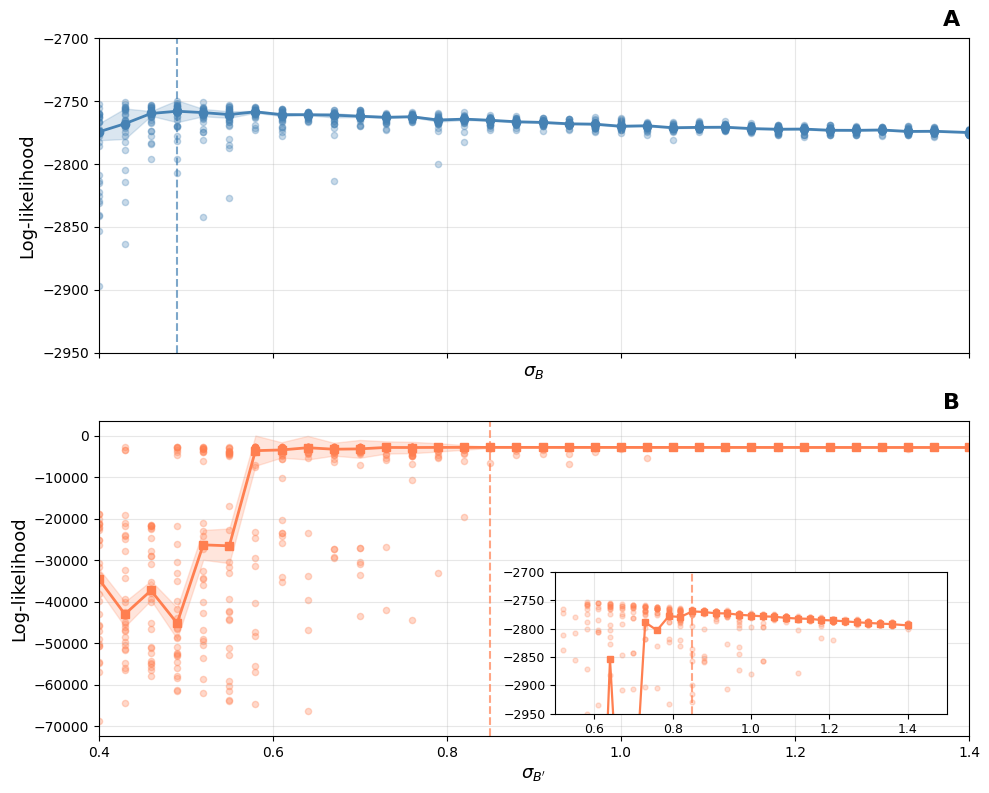

In [33]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# Split figure into two stacked panels
# Top: Normal Rt with sigma_B
# Bottom: Log Rt with sigma_{B'}
# ============================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    sharey=False
)

ax1, ax2 = axes

# Repeat sigma values to match shape (n_sigma, n_repl) → flattened
sigma_rep_normal = np.repeat(sigma_values, logL_all_normal.shape[1])
sigma_rep_log    = np.repeat(sigma_values, logL_all_log.shape[1])

# Flatten log-likelihood arrays
ll_normal_flat = logL_all_normal.flatten()
ll_log_flat    = logL_all_log.flatten()

# ============================================================
# Panel A: Normal Rt / sigma_B
# ============================================================
ax1.scatter(
    sigma_rep_normal,
    ll_normal_flat,
    color="steelblue",
    alpha=0.3,
    s=20,
    label=r"Normal $R_t$ replicates"
)

ax1.plot(
    sigma_values,
    median_normal,
    "o-",
    color="steelblue",
    linewidth=2.0,
    markersize=6,
    label=r"Normal $R_t$ median"
)

ax1.fill_between(
    sigma_values,
    median_normal - stderr_normal,
    median_normal + stderr_normal,
    color="steelblue",
    alpha=0.2,
    label="±1 SE"
)

ax1.axvline(
    x=0.49,
    color="steelblue",
    linestyle="--",
    alpha=0.7
)

ax1.set_xlabel(r"$\sigma_B$", fontsize=13)
ax1.set_ylabel("Log-likelihood", fontsize=13)
ax1.set_xlim(0.4, 1.4)
ax1.set_ylim(-2950, -2700)
ax1.grid(True, alpha=0.3)

# Panel label
ax1.text(
    0.97, 1.09, "A",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)

# ============================================================
# Panel B: Log Rt / sigma_B'
# ============================================================
ax2.scatter(
    sigma_rep_log,
    ll_log_flat,
    color="coral",
    alpha=0.3,
    s=20,
    label=r"Log $R_t$ replicates"
)

ax2.plot(
    sigma_values,
    median_log,
    "s-",
    color="coral",
    linewidth=2.0,
    markersize=6,
    label=r"Log $R_t$ median"
)

ax2.fill_between(
    sigma_values,
    median_log - stderr_log,
    median_log + stderr_log,
    color="coral",
    alpha=0.2,
    label="±1 SE"
)

ax2.axvline(
    x=0.85,
    color="coral",
    linestyle="--",
    alpha=0.7
)

ax2.set_xlabel(r"$\sigma_{B'}$", fontsize=13)
ax2.set_ylabel("Log-likelihood", fontsize=13)
ax2.set_xlim(0.4, 1.4)
ax2.grid(True, alpha=0.3)

# Panel label
ax2.text(
    0.97, 1.09, "B",
    transform=ax2.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)

# ============================================================
# Inset for Panel B: narrower y-axis range
# ============================================================
axins = inset_axes(
    ax2,
    width="45%",
    height="45%",
    loc="lower right",
    borderpad=1.6
)

axins.scatter(
    sigma_rep_log,
    ll_log_flat,
    color="coral",
    alpha=0.25,
    s=12
)

axins.plot(
    sigma_values,
    median_log,
    "s-",
    color="coral",
    linewidth=1.6,
    markersize=4
)

#axins.fill_between(
#    sigma_values,
#    median_log - stderr_log,
#    median_log + stderr_log,
#    color="coral",
#    alpha=0.2)

axins.axvline(
    x=0.85,
    color="coral",
    linestyle="--",
    alpha=0.7
)

axins.set_xlim(0.5, 1.5)
axins.set_ylim(-2950, -2700)
axins.grid(True, alpha=0.3)

axins.tick_params(axis="both", labelsize=9)
#axins.set_title("Zoomed y-axis", fontsize=10)

plt.tight_layout()
plt.show()

### Model selection with or without env stochasticity 

In [34]:
ZH_ww_selected     = pd.read_csv('data/ZH_ww_selected.csv',        header=None)[0].to_numpy()
ZH_case_selected   = pd.read_csv('data/ZH_case_selected.csv',      header=None)[0].to_numpy()
case_empt         = pd.read_csv('data/case_empt.csv',              header=None)[0].to_numpy()
ww_empt           = pd.read_csv('data/ww_empt.csv',                header=None)[0].to_numpy()

In [35]:
n = 40 # Number of compartments
n_particles = 1000
c_i = util.generate_neg_binom(n, 11.528428093645484, 0.8) # Case detection profile
omega_i = util.generate_neg_binom(n, 3.1515151515151514, 0.24444444444444444) # Shedding load profile
f_i= util.generate_neg_binom(n, 3.8989898989898992, 0.4473684210526315) # Infectivity profile 
dt_real = 0.1


In [37]:
# WW with env noise 
eps_ww_out = np.round(np.arange(0.50, 2.9 + 0.001, 0.05), 2).tolist()
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 0.32,  # Initial standard deviation for Brownian motion
    "lambda_ww": 2.02e10,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    # "sigma_ww": 3e12,  # Measurement noise in wastewater 
    "sigma_w":2.2114e12, # Std in ww
    "k_c" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0.95,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.3 # Reporting rate (fraction of actual infections reported)
}

logL_all_ww = np.full((len(sigma_Re_value), len(eps_ww_out), n_repl), np.nan)
mean_ll_array_ww = np.full((len(sigma_Re_value), len(eps_ww_out)), np.nan) 
medianll_array_ww = np.full((len(sigma_Re_value), len(eps_ww_out)), np.nan) 

for i, sigma in enumerate(sigma_Re_value):
    epiparams["sigma_Re"] = sigma
    for j, eps in enumerate(eps_ww_out):
        epiparams["eps_ww_out"] = eps
        for r in range(n_repl):
            try:
                theta_logL, recon = get_logL_ZH_enfout(
                    case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18
                )
                if np.isfinite(theta_logL):
                    logL_all_ww[i, j, r] = theta_logL
            except util.ModelNumericsError:
                # skip this replicate
                continue
            except KeyboardInterrupt:
                raise
            except Exception as e:
                # unexpected error — skip (optionally log e)
                continue

        cell_vals = logL_all_ww[i, j, :]
        if np.all(np.isnan(cell_vals)):
            mean_ll_array_ww[i, j]   = -np.inf
            medianll_array_ww[i, j]  = -np.inf
        else:
            mean_ll_array_ww[i, j]   = np.nanmean(cell_vals)
            medianll_array_ww[i, j]  = np.nanmedian(cell_vals)

#np.save("mean_logL_ZH_out_ww_std2e12.npy", mean_ll_array_ww)
#np.save("median_logL_ZH_out_ww_std2e12.npy", medianll_array_ww)
#np.save("logL_all_ZH_out_ww_std2e12.npy", logL_all_ww)
    

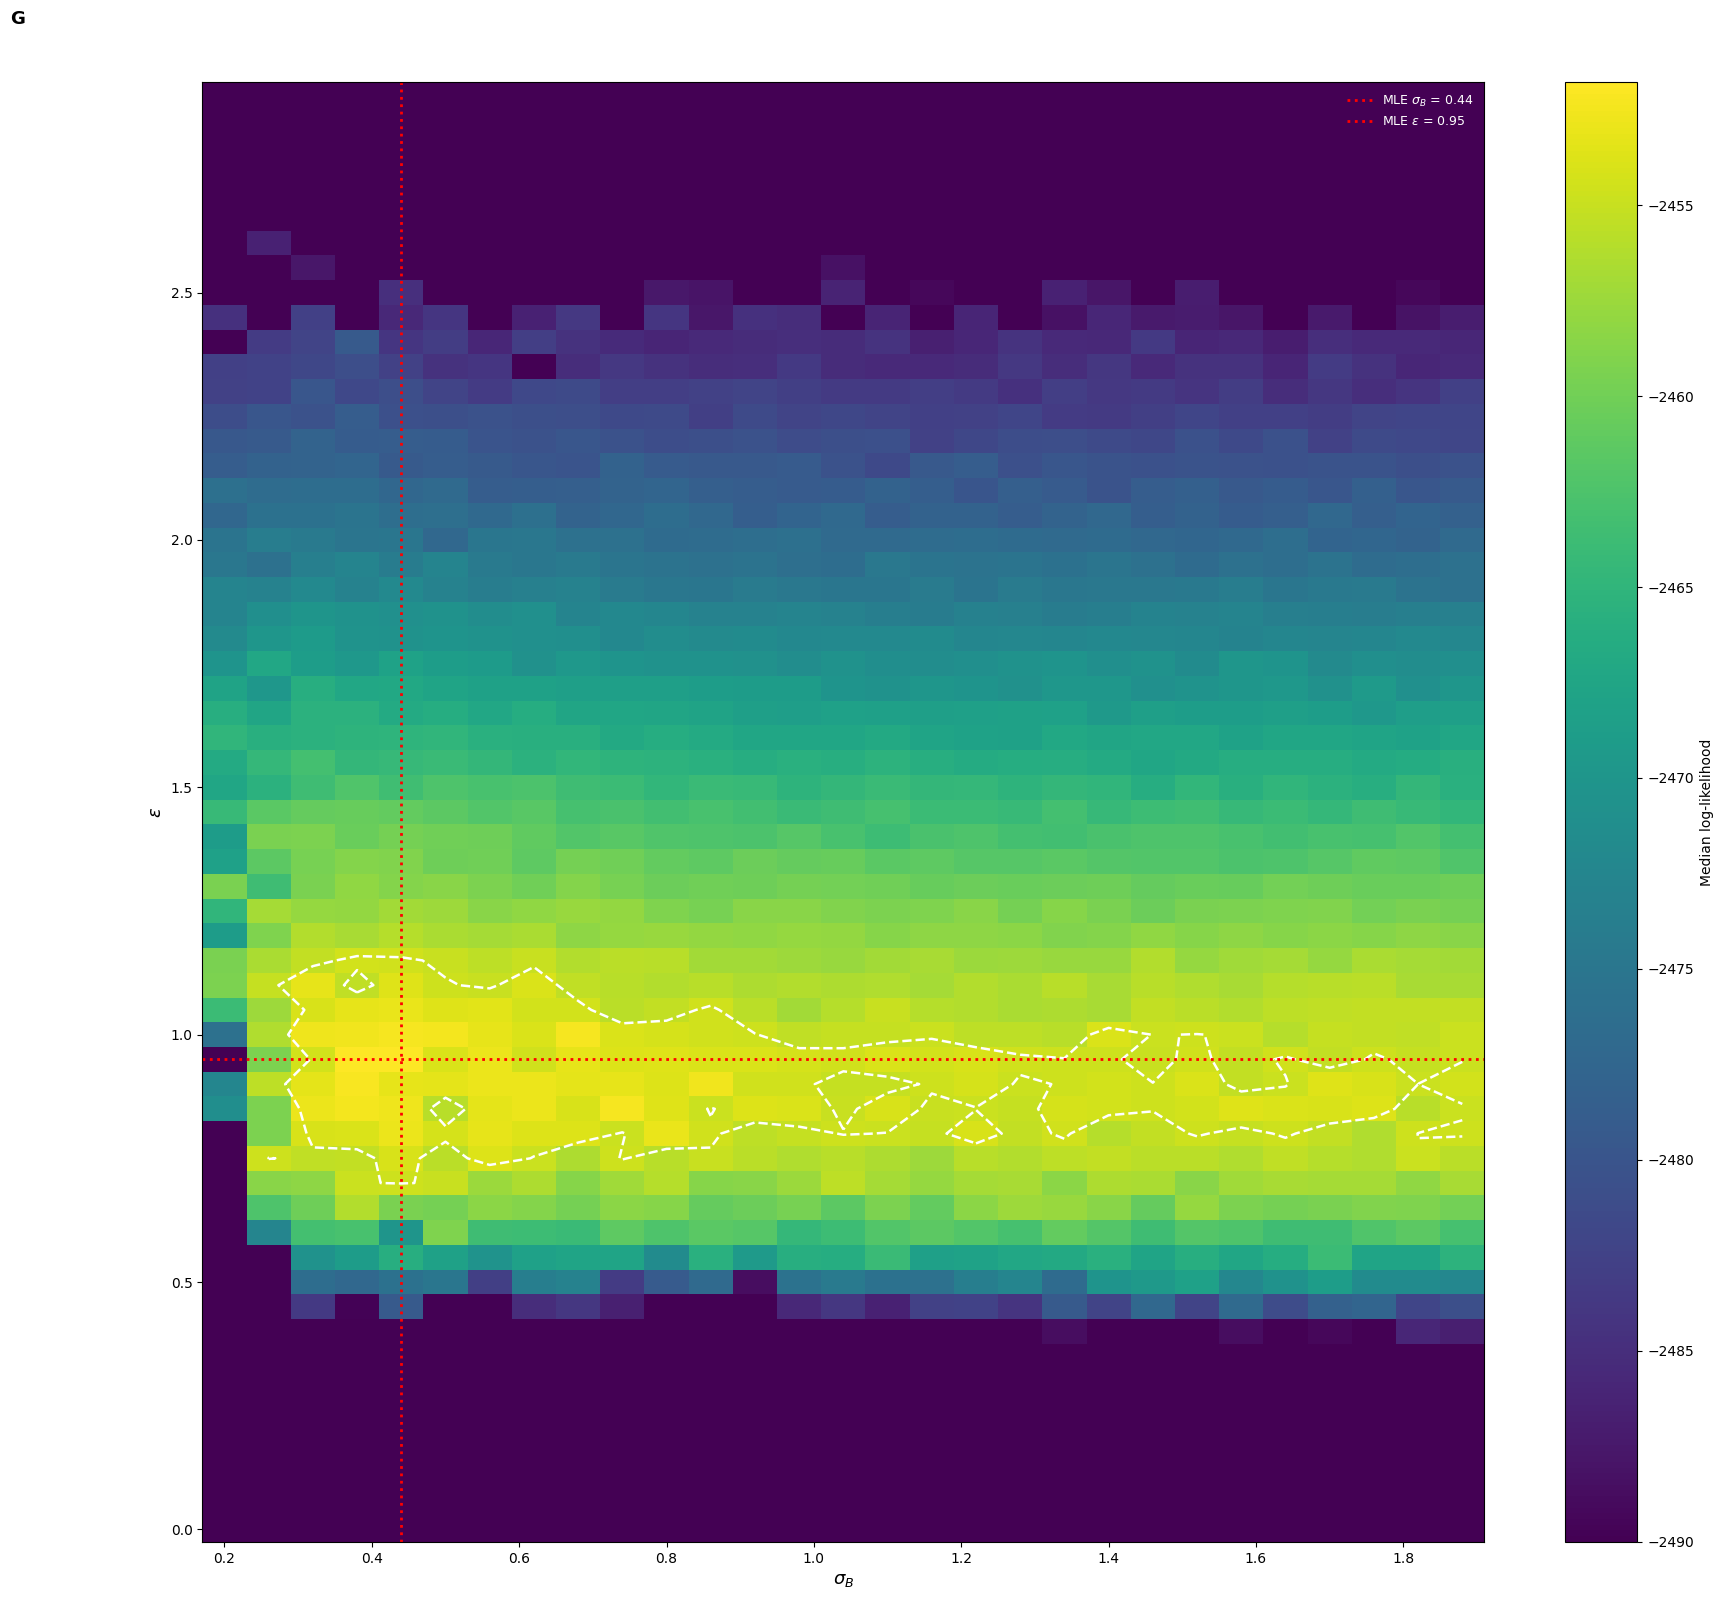

In [39]:
median_ll_array_ww = np.load('supp_results/median_logL_ZH_review.npy')
median_ll_array_ww_replot = median_ll_array_ww.copy()
median_ll_array_ww_replot[median_ll_array_ww_replot < -2490] = -2490
eps_ww_out = np.round(np.arange(0, 2.9 + 0.001, 0.05), 2).tolist()
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

label_font = {'fontsize': 13}
fig, axG = plt.subplots(
    1, 1, figsize=(18, 16),              
    constrained_layout=False       
)
eps_ww_out = np.round(np.arange(0, 2.9 + 0.001, 0.05), 2).tolist()
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

X = np.asarray(sigma_Re_value)    # x-axis (σ_B)
Y = np.asarray(eps_ww_out)        # y-axis (ε)
SigmaGrid, EpsGrid = np.meshgrid(X, Y)

# --- Panel G (σRe vs λww log-likelihood heat-map with out noise) ---
hm = axG.pcolormesh(SigmaGrid, EpsGrid, median_ll_array_ww_replot.T,
                    cmap="viridis", shading="auto")
fig.colorbar(hm, ax=axG, label="Median log-likelihood")

Lmax = median_ll_array_ww_replot.max()
threshold = Lmax - 2.996

cs = axG.contour(X, Y, median_ll_array_ww_replot.T, levels=[threshold], colors="white",
                 linestyles="--", linewidths=1.8)

# MLE lines
i_max, j_max = np.unravel_index(np.argmax(median_ll_array_ww_replot.T),
                                median_ll_array_ww_replot.T.shape)
mle_sigma    = sigma_Re_value[j_max]  # note: meshgrid orientation
mle_epsilon  = eps_ww_out[i_max]
axG.axvline(mle_sigma, color="red", linestyle=":", linewidth=2,
            label=fr"MLE $σ_{{B}}$ = {mle_sigma:.3g}")
axG.axhline(mle_epsilon, color="red", linestyle=":", linewidth=2,
            label=fr"MLE $ε$ = {mle_epsilon:.2f}")

legG = axG.legend(loc="upper right", fontsize=9, framealpha=0)

for text in legG.get_texts():
    text.set_color("white")


axG.set_xlabel(r"$\sigma_{B}$", **label_font)
axG.set_ylabel(r"$\varepsilon$", **label_font)
axG.text(-0.15, 1.04, "G", transform=axG.transAxes,
         **label_font, fontweight="bold")


plt.tight_layout()
plt.show()

Best-fit epsilon: 0.95
Maximum log-likelihood: -2451.79
Confidence level: 95.00%
Delta log-likelihood: 1.92073
Threshold: -2453.71
95.00% CI for epsilon: [0.8, 1.1]


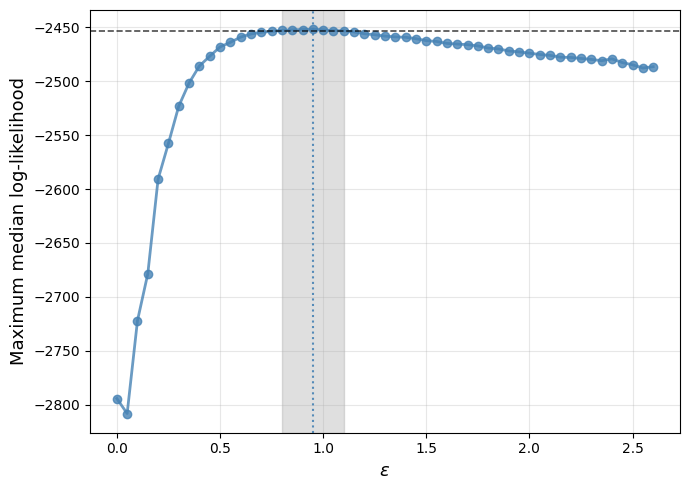

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ------------------------------------------------------------
# 0. Make sure epsilon values are a NumPy array
# ------------------------------------------------------------

eps_ww_out = np.asarray(eps_ww_out)

# ------------------------------------------------------------
# 1. Extract maximum median log-likelihood for each epsilon
# ------------------------------------------------------------

max_logL_by_eps = []

for j, eps in enumerate(eps_ww_out):
    logL_col = median_ll_array_ww[:, j]

    valid_mask = np.isfinite(logL_col)

    if np.any(valid_mask):
        max_idx_valid = np.argmax(logL_col[valid_mask])
        max_idx = np.where(valid_mask)[0][max_idx_valid]
        max_logL_by_eps.append(logL_col[max_idx])
    else:
        max_logL_by_eps.append(np.nan)

max_logL_by_eps = np.asarray(max_logL_by_eps)


# ------------------------------------------------------------
# 2. Calculate profile-likelihood CI for epsilon
# ------------------------------------------------------------

df = 1
confidence_level = 0.95

delta_logL = 0.5 * chi2.ppf(confidence_level, df=df)

Lmax = np.nanmax(max_logL_by_eps)
threshold = Lmax - delta_logL

ci_mask = np.isfinite(max_logL_by_eps) & (max_logL_by_eps >= threshold)

epsilon_ci_low = np.nanmin(eps_ww_out[ci_mask])
epsilon_ci_high = np.nanmax(eps_ww_out[ci_mask])

best_eps = eps_ww_out[np.nanargmax(max_logL_by_eps)]

print(f"Best-fit epsilon: {best_eps:.6g}")
print(f"Maximum log-likelihood: {Lmax:.6g}")
print(f"Confidence level: {confidence_level * 100:.2f}%")
print(f"Delta log-likelihood: {delta_logL:.6g}")
print(f"Threshold: {threshold:.6g}")
print(
    f"{confidence_level * 100:.2f}% CI for epsilon: "
    f"[{epsilon_ci_low:.6g}, {epsilon_ci_high:.6g}]"
)


# ------------------------------------------------------------
# 3. Plot profile log-likelihood and shaded CI
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.axvspan(
    epsilon_ci_low,
    epsilon_ci_high,
    color='gray',
    alpha=0.25,
    label=rf'{confidence_level * 100:.0f}% CI: '
          rf'[{epsilon_ci_low:.3g}, {epsilon_ci_high:.3g}]'
)

ax.plot(
    eps_ww_out,
    max_logL_by_eps,
    'o-',
    color='steelblue',
    linewidth=2.0,
    markersize=6,
    alpha=0.8,
    label='Profile median log-likelihood'
)

ax.axvline(
    best_eps,
    color='steelblue',
    linestyle=':',
    linewidth=1.5,
    alpha=0.9,
    label=rf'Best fit $\varepsilon$ = {best_eps:.3g}'
)

ax.axhline(
    threshold,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=rf'95% threshold: $\ell_{{max}} - {delta_logL:.3g}$'
)

ax.set_xlabel(r'$\varepsilon$', fontsize=13)
ax.set_ylabel('Maximum median log-likelihood', fontsize=13)
ax.grid(True, alpha=0.3)
# ax.legend(frameon=False)

plt.tight_layout()
plt.show()

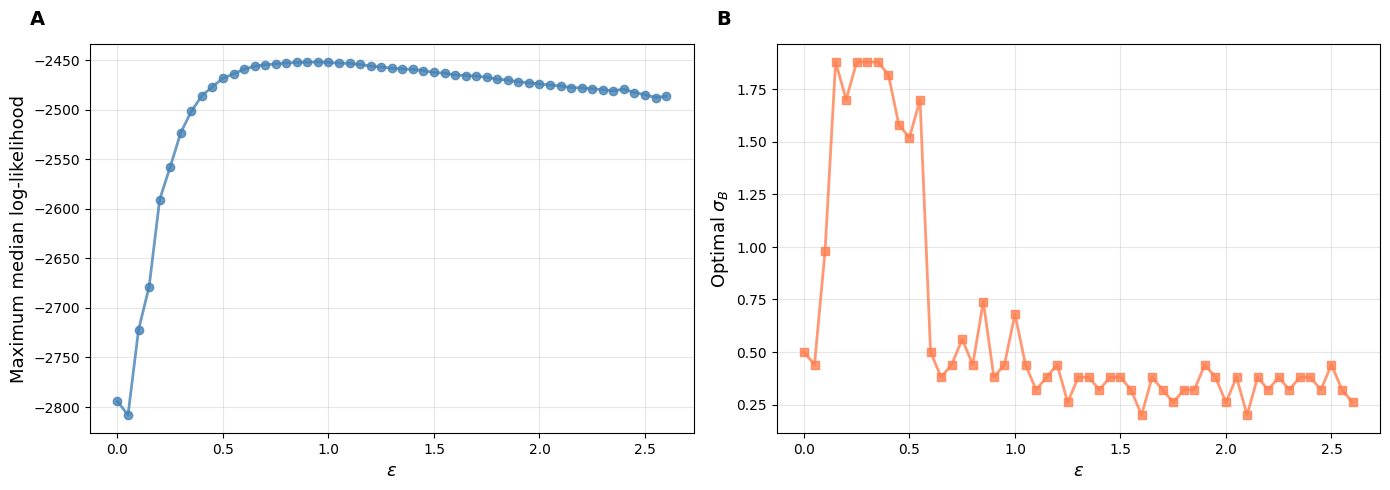

In [41]:
# Extract maximum log-likelihood and corresponding sigma for each epsilon value
max_logL_by_eps = []
best_sigma_by_eps = []

for j, eps in enumerate(eps_ww_out):
    # Get the median log-likelihood column for this epsilon
    logL_col = median_ll_array_ww[:, j]
    
    # Find the index of the maximum (ignoring -inf values)
    valid_mask = np.isfinite(logL_col)
    if np.any(valid_mask):
        max_idx = np.argmax(logL_col[valid_mask])
        # Map back to original index
        max_idx = np.where(valid_mask)[0][max_idx]
        max_logL_by_eps.append(logL_col[max_idx])
        best_sigma_by_eps.append(sigma_Re_value[max_idx])
    else:
        max_logL_by_eps.append(np.nan)
        best_sigma_by_eps.append(np.nan)

max_logL_by_eps = np.array(max_logL_by_eps)
best_sigma_by_eps = np.array(best_sigma_by_eps)

# Create figure with two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Maximum log-likelihood vs epsilon
ax1.plot(eps_ww_out, max_logL_by_eps, 'o-', color='steelblue', 
         linewidth=2.0, markersize=6, alpha=0.8)
ax1.set_xlabel(r'$\varepsilon$', fontsize=13)
ax1.set_ylabel('Maximum median log-likelihood', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, 
         fontsize=14, fontweight='bold')

# Panel 2: Best sigma value vs epsilon
ax2.plot(eps_ww_out, best_sigma_by_eps, 's-', color='coral', 
         linewidth=2.0, markersize=6, alpha=0.8)
ax2.set_xlabel(r'$\varepsilon$', fontsize=13)
ax2.set_ylabel(r'Optimal $\sigma_B$', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, 
         fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Maximum-likelihood estimates and confidence contours are stable with respect to the number of particles and independent filter runs

In [60]:
median_ll_array_2xrepl = np.load('supp_results/median_logL_ZH_out_both_2xrepl.npy')
median_ll_array_both_original = np.load('ZH_results/median_logL_ZH_out_both.npy')
median_ll_array_2xparticle = np.load('supp_results/median_logL_ZH_out_both_2xparticle.npy')

lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value    = np.linspace(0.05, 0.6, 18)

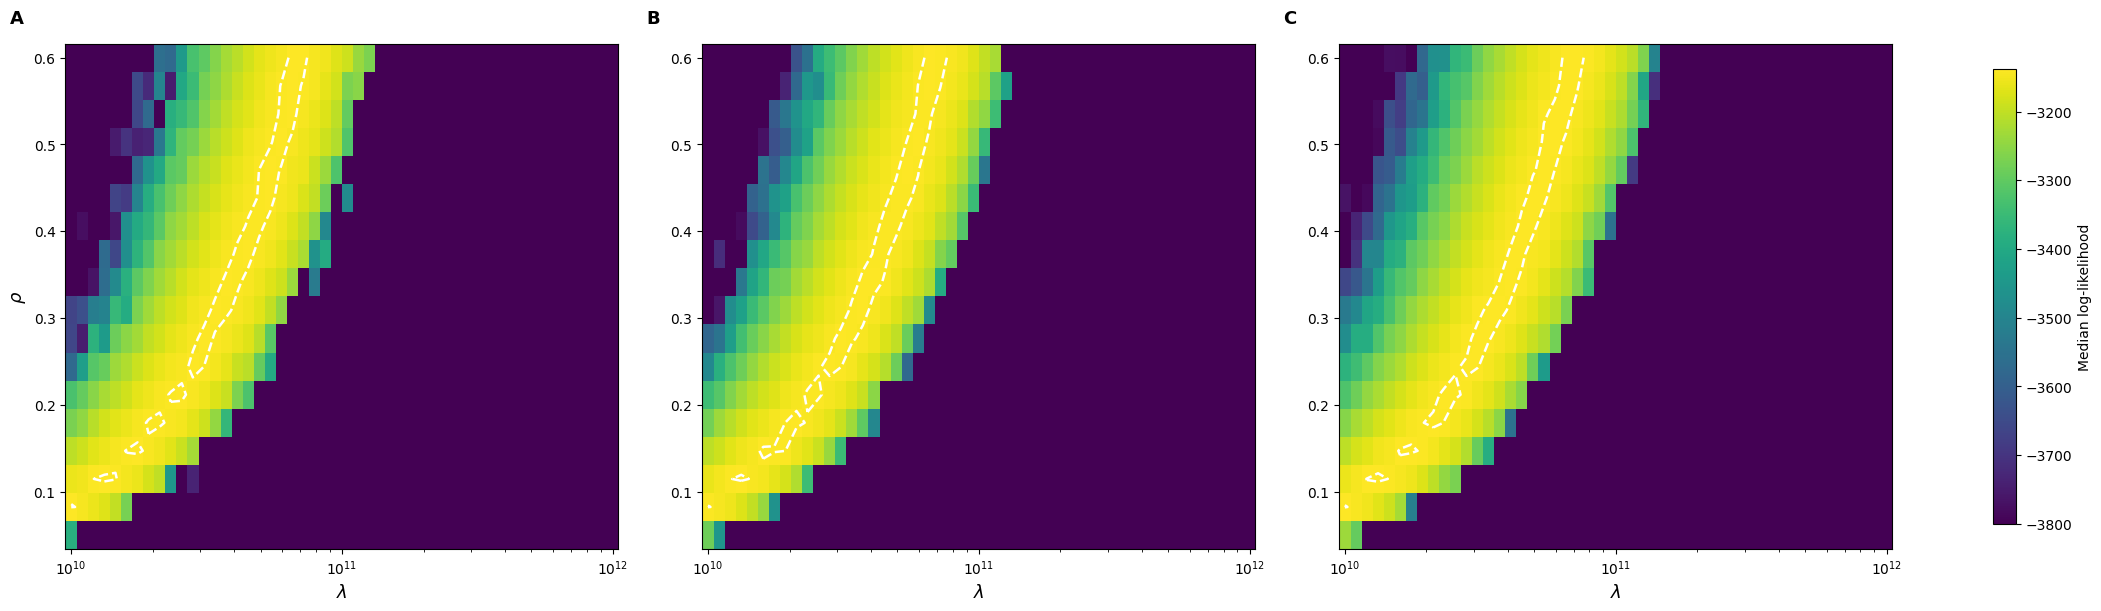

In [67]:
lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value    = np.linspace(0.05, 0.6, 18)

# --- clip all three at -2490 ---
arrays = {
    "A": ("Original",     median_ll_array_both_original),
    "B": ("2x replicates", median_ll_array_2xrepl),
    "C": ("2x particles",  median_ll_array_2xparticle),
}
clipped = {}
for k, (name, arr) in arrays.items():
    a = arr.copy()
    a[a < -3800] = -3800
    clipped[k] = (name, a)

X = np.asarray(lambda_value)   # x-axis (lambda)
Y = np.asarray(rho_value)      # y-axis (rho)
LamGrid, RhoGrid = np.meshgrid(X, Y)

# shared colour scale so panels are directly comparable
vmin = min(a.min() for _, a in clipped.values())
vmax = max(a.max() for _, a in clipped.values())

label_font = {'fontsize': 13}
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for ax, key in zip(axes, ["A", "B", "C"]):
    name, arr = clipped[key]
    Z = arr.T                                   # -> (n_rho, n_lambda)

    hm = ax.pcolormesh(LamGrid, RhoGrid, Z, cmap="viridis",
                       shading="auto", vmin=vmin, vmax=vmax)

    # 95% CI contour (per-panel maximum)
    threshold = Z.max() - 2.996
    ax.contour(X, Y, Z, levels=[threshold], colors="white",
               linestyles="--", linewidths=1.8)

    # MLE lines
    i_max, j_max = np.unravel_index(np.argmax(Z), Z.shape)   # i -> rho, j -> lambda
    mle_lambda = lambda_value[j_max]
    mle_rho    = rho_value[i_max]

    # leg = ax.legend(loc="upper right", fontsize=9, framealpha=0)
    #for text in leg.get_texts():text.set_color("white")

    ax.set_xscale("log")                        # lambda spans 1e10–1e12
    ax.set_xlabel(r"$\lambda$", **label_font)
    # ax.set_title(name, fontsize=12)
    ax.text(-0.10, 1.04, key, transform=ax.transAxes,
            **label_font, fontweight="bold")

axes[0].set_ylabel(r"$\rho$", **label_font)

fig.colorbar(hm, ax=axes, label="Median log-likelihood", shrink=0.9)
plt.show()